In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [78]:
walmart_data = pd.read_csv('data/walmart-sales-dataset-of-45stores.csv')

In [7]:
walmart_data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [79]:
walmart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [80]:
## Change the 'Date' column to datetime format
walmart_data['Date'] = pd.to_datetime(walmart_data['Date'], format='%d-%m-%Y') 

<Axes: xlabel='Date'>

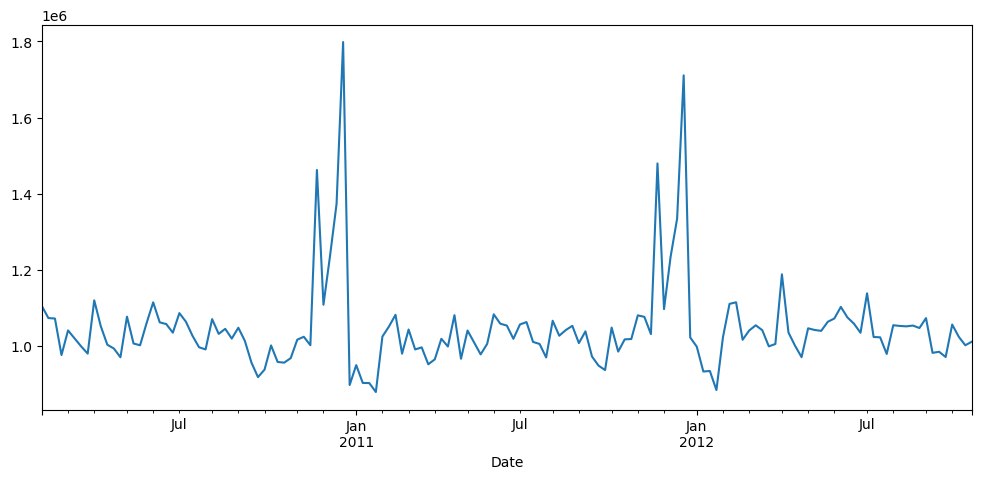

In [81]:
## Average weekly sales over time 
walmart_data.groupby('Date')['Weekly_Sales'].mean().plot(figsize=(12,5))

<Axes: >

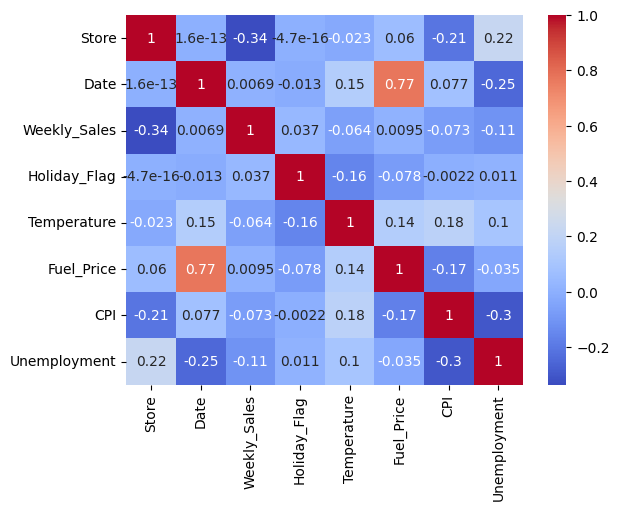

In [82]:
## Correlations
import seaborn as sns
sns.heatmap(walmart_data.corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='Month'>

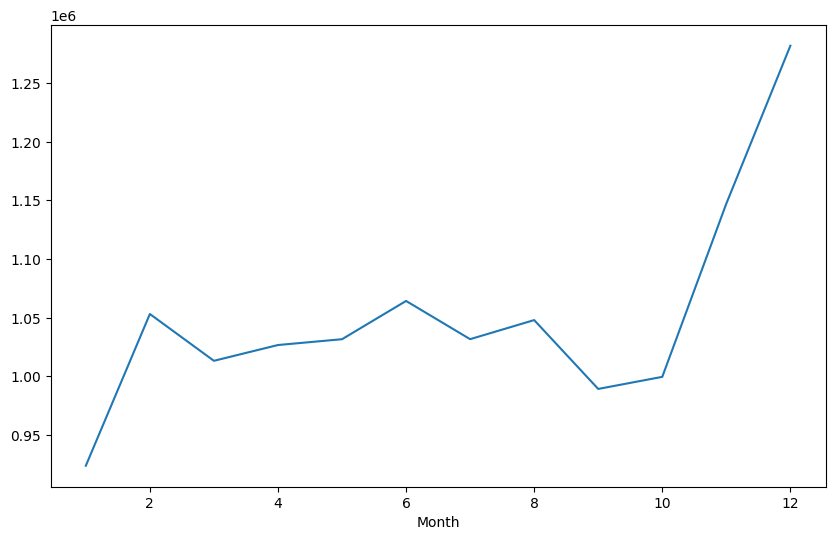

In [83]:
## Per month
walmart_data['Month'] = walmart_data['Date'].dt.month
monthly_sales = walmart_data.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(kind='line', figsize=(10,6))

In [84]:
## Some feature engineering
walmart_data['Year'] = walmart_data['Date'].dt.year
walmart_data['Weekday'] = walmart_data['Date'].dt.weekday

In [85]:
walmart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Month         6435 non-null   int32         
 9   Year          6435 non-null   int32         
 10  Weekday       6435 non-null   int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(2)
memory usage: 477.7 KB


In [92]:
# Sum across all stores
ts = (walmart_data
      .groupby("Date", as_index=False)["Weekly_Sales"]
      .sum()
      .sort_values("Date")
      .set_index("Date"))

y = ts["Weekly_Sales"]

# --- 3) Chronological split (e.g., last 20% as test) ---
test_size = 0.20
split_idx = int(len(y) * (1 - test_size))

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

Date
2012-04-13    46629261.41
2012-04-20    45072529.78
2012-04-27    43716798.89
2012-05-04    47124197.93
2012-05-11    46925878.99
Name: Weekly_Sales, dtype: float64

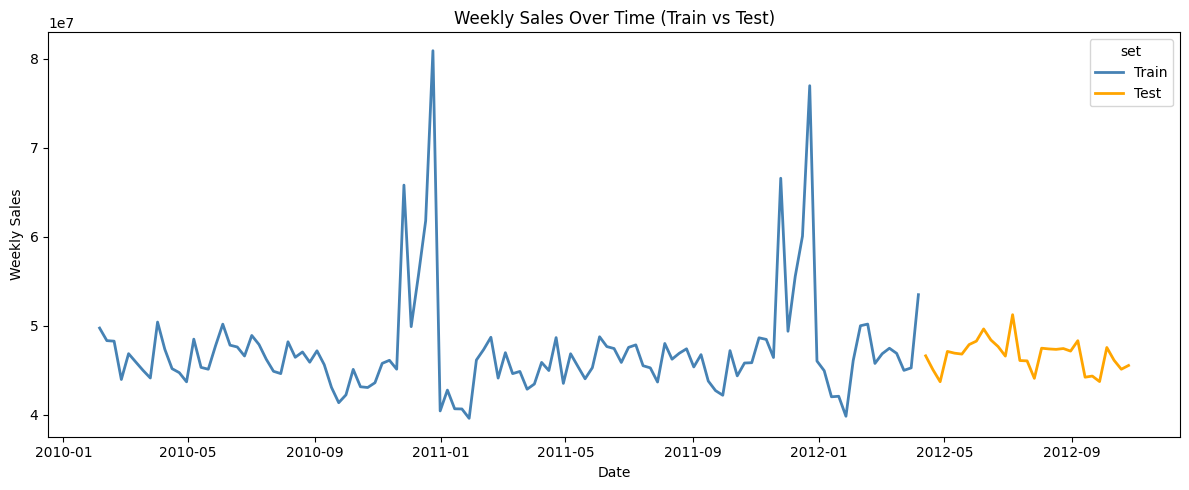

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reconstruct a plotting DataFrame
plot_df = ts.copy()

# Create train / test labels based on the split indices
plot_df["set"] = "Train"
plot_df.loc[y_test.index, "set"] = "Test"

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=plot_df,
    x="Date",
    y="Weekly_Sales",
    hue="set",
    palette={"Train": "steelblue", "Test": "orange"},
    linewidth=2
)

plt.title("Weekly Sales Over Time (Train vs Test)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

Next, we perform time series prediction using naive and naive seasonal models. The naive model just uses the last available real value as the predicted and the naive seasonal uses the value from the same week in the previous year. These will function as essential baselines to compared our future models to. 

In [100]:
# --- 4) Naive forecast: predict last observed train value for all test points ---
y_pred_naive = pd.Series(y_train.iloc[-1], index=y_test.index, name="Naive")

# --- 5) Seasonal naive: predict value from same week last year (52 weeks back) ---
season_len = 52
y_pred_seasonal_naive = y.shift(season_len).loc[y_test.index]
y_pred_seasonal_naive.name = "Seasonal Naive"

# Fill any missing seasonal values (e.g., if first test dates have no t-52 history)
y_pred_seasonal_naive = y_pred_seasonal_naive.fillna(y_pred_naive)


In [101]:
# --- 6) Metrics ---
metrics = pd.DataFrame({
    "Model": ["Naive", "Seasonal Naive"],
    "MSE": [
        mean_squared_error(y_test, y_pred_naive),
        mean_squared_error(y_test, y_pred_seasonal_naive)
    ],
    "R2": [
        r2_score(y_test, y_pred_naive),
        r2_score(y_test, y_pred_seasonal_naive)
    ]
})
print(metrics)


            Model           MSE         R2
0           Naive  4.933139e+13 -15.468359
1  Seasonal Naive  2.442706e+12   0.184548


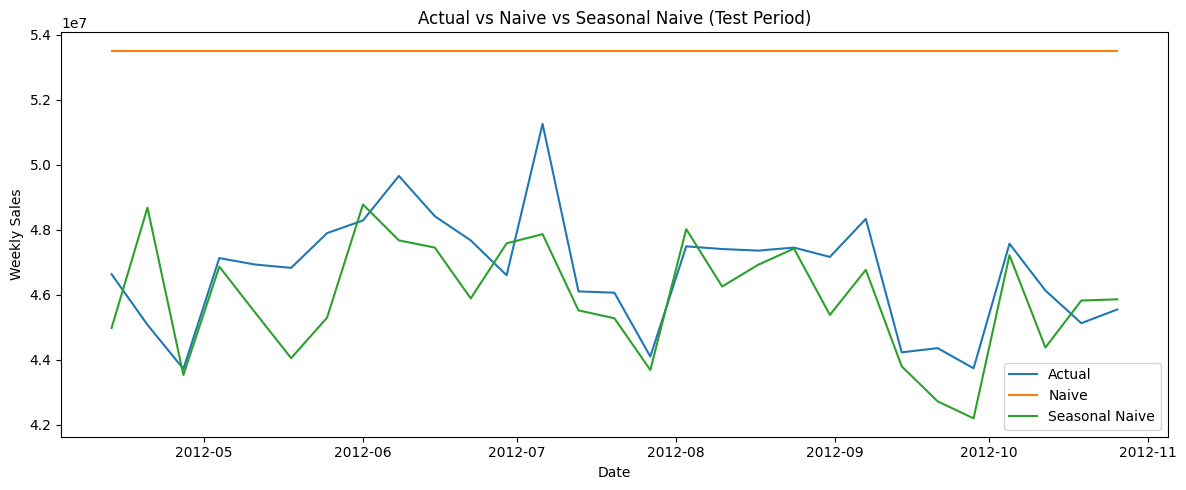

In [102]:
# --- 7) Plot actual vs forecasts ---
plot_df = pd.DataFrame({
    "Actual": y_test,
    "Naive": y_pred_naive,
    "Seasonal Naive": y_pred_seasonal_naive
}).reset_index().rename(columns={"Date": "Date"})

plt.figure(figsize=(12, 5))
sns.lineplot(data=plot_df, x="Date", y="Actual", label="Actual")
sns.lineplot(data=plot_df, x="Date", y="Naive", label="Naive")
sns.lineplot(data=plot_df, x="Date", y="Seasonal Naive", label="Seasonal Naive")
plt.title("Actual vs Naive vs Seasonal Naive (Test Period)")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Framewo

Best ARIMA order by AIC: (2, 1, 2)  |  AIC: 3859.87
ARIMA(2, 1, 2)  MSE: 5,814,631,006,077.59
ARIMA(2, 1, 2)  R² : -0.9411


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W

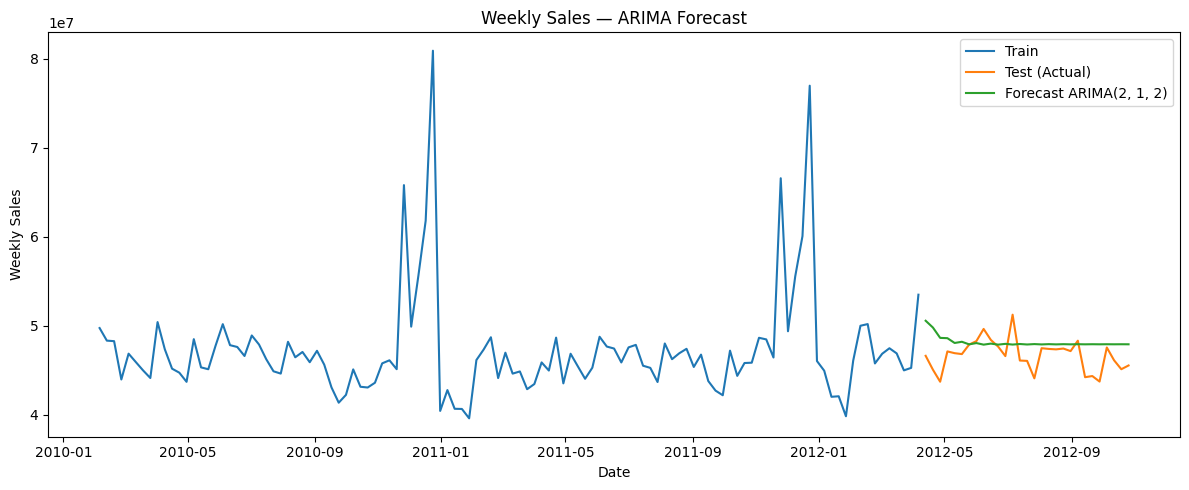

In [103]:
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

best_aic = np.inf
best_order = None
best_model = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(y_train, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_model = fitted
            except Exception:
                continue

print(f"Best ARIMA order by AIC: {best_order}  |  AIC: {best_aic:.2f}")

# -----------------------------
# 4) Forecast over test horizon
# -----------------------------
n_test = len(y_test)
forecast = best_model.forecast(steps=n_test)
forecast.index = y_test.index  # align for clean plotting/metrics

# -----------------------------
# 5) Metrics
# -----------------------------
mse = mean_squared_error(y_test, forecast)
r2 = r2_score(y_test, forecast)

print(f"ARIMA{best_order}  MSE: {mse:,.2f}")
print(f"ARIMA{best_order}  R² : {r2:.4f}")

# -----------------------------
# 6) Plot
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Test (Actual)")
plt.plot(forecast.index, forecast, label=f"Forecast ARIMA{best_order}")
plt.title("Weekly Sales — ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.tight_layout()
plt.show()

NEED TO FIX THE BELOW TO ALIGN WITH ABOVE SPLITS THEN PLOT ALL TOGETHER AND COMPARE. 

Boosted Model (lags/rollings only) | XGBoost  ->  MSE: 4,183,304,723.13 | R^2: 0.9851


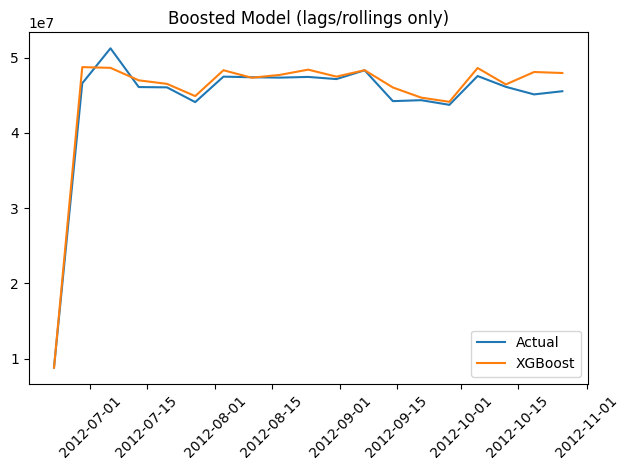

Boosted Model (lags/rollings + covariates) | XGBoost  ->  MSE: 3,776,638,535.10 | R^2: 0.9866


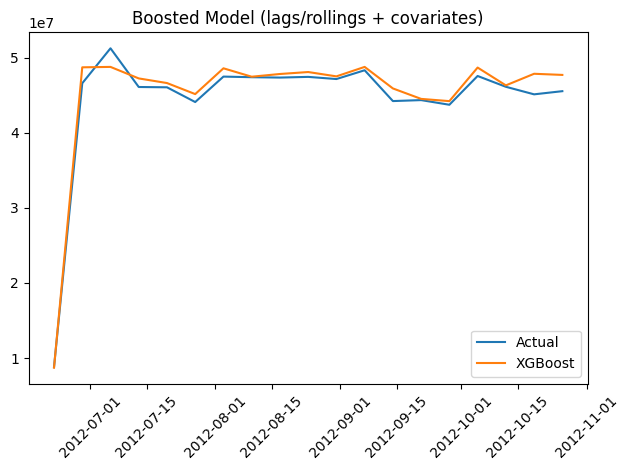

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Ensure Date is datetime
walmart_data = walmart_data.copy()

# -----------------------------
# 2) Feature engineering function that works with group_col=None or "Store"
#    (If you already have make_ts_features, you can replace it with this safe version)
# -----------------------------
def make_ts_features(df, date_col="Date", target_col="Weekly_Sales", group_col="Store"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    if group_col is None:
        df = df.sort_values([date_col]).reset_index(drop=True)
        g = [None]
        groups = [(None, df)]
    else:
        df = df.sort_values([group_col, date_col]).reset_index(drop=True)
        groups = list(df.groupby(group_col, sort=False))

    # calendar features
    df["year"] = df[date_col].dt.year
    df["month"] = df[date_col].dt.month
    df["weekofyear"] = df[date_col].dt.isocalendar().week.astype(int)
    df["dayofweek"] = df[date_col].dt.dayofweek

    # allocate columns
    for lag in [1, 2, 4, 8, 52]:
        df[f"lag_{lag}"] = np.nan
    for w in [4, 8, 12]:
        df[f"roll_mean_{w}"] = np.nan
        df[f"roll_std_{w}"] = np.nan

    # compute per group
    for key, sub in groups:
        idx = sub.index
        y = df.loc[idx, target_col]

        for lag in [1, 2, 4, 8, 52]:
            df.loc[idx, f"lag_{lag}"] = y.shift(lag)

        # rolling stats on shifted target (prevents leakage)
        y_shift = y.shift(1)
        for w in [4, 8, 12]:
            df.loc[idx, f"roll_mean_{w}"] = y_shift.rolling(w).mean()
            df.loc[idx, f"roll_std_{w}"] = y_shift.rolling(w).std()

    return df

# Build features (group by Store if present)
group_col = "Store" if "Store" in walmart_data.columns else None
df_feat = make_ts_features(walmart_data, date_col="Date", target_col="Weekly_Sales", group_col=group_col)

# One-hot Store identity if present (optional but often helps)
if "Store" in df_feat.columns:
    df_feat = pd.get_dummies(df_feat, columns=["Store"], drop_first=True)

# -----------------------------
# 3) Choose feature sets:
#    A) "No extra covariates" = time + lags + rollings (+ store identity)
#    B) "With covariates"     = add Temperature/Fuel/CPI/Unemployment/Holiday_Flag if present
# -----------------------------
base_feats = (
    ["year", "month", "weekofyear", "dayofweek"]
    + [c for c in df_feat.columns if c.startswith("lag_")]
    + [c for c in df_feat.columns if c.startswith("roll_")]
    + [c for c in df_feat.columns if c.startswith("Store_")]
)

covariates = [c for c in ["Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment"] if c in df_feat.columns]
feats_with_cov = base_feats + covariates

# Drop rows where we don't have lag/rolling info yet
df_model_base = df_feat.dropna(subset=base_feats + ["Weekly_Sales"]).copy()
df_model_cov  = df_feat.dropna(subset=feats_with_cov + ["Weekly_Sales"]).copy()

# -----------------------------
# 4) Chronological split INSIDE df_model (solves your index mismatch)
# -----------------------------
def chrono_split(df, date_col="Date", test_size=0.2):
    df = df.sort_values(date_col).reset_index(drop=True)
    cut = int(len(df) * (1 - test_size))
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()

train_base, test_base = chrono_split(df_model_base, date_col="Date", test_size=0.2)
train_cov,  test_cov  = chrono_split(df_model_cov,  date_col="Date", test_size=0.2)

# -----------------------------
# 5) Fit model: try XGBoost; if your xgboost is weird, fall back to sklearn booster
#    (NO early stopping to avoid your fit() TypeError)
# -----------------------------
def fit_and_eval(train_df, test_df, feature_cols, title):
    Xtr, ytr = train_df[feature_cols], train_df["Weekly_Sales"]
    Xte, yte = test_df[feature_cols],  test_df["Weekly_Sales"]

    model_name = ""
    try:
        from xgboost import XGBRegressor
        model = XGBRegressor(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=123,
            n_jobs=-1,
        )
        model.fit(Xtr, ytr)  # <-- no early_stopping_rounds/callbacks
        model_name = "XGBoost"
    except Exception as e:
        from sklearn.ensemble import HistGradientBoostingRegressor
        model = HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=800,
            random_state=123
        )
        model.fit(Xtr, ytr)
        model_name = "HistGradientBoosting (fallback)"

    pred = model.predict(Xte)
    mse = mean_squared_error(yte, pred)
    r2  = r2_score(yte, pred)

    print(f"{title} | {model_name}  ->  MSE: {mse:,.2f} | R^2: {r2:.4f}")

    # Plot (aggregate across stores by date for a clean chart)
    plot_df = test_df[["Date", "Weekly_Sales"]].copy()
    plot_df["pred"] = pred
    plot_agg = plot_df.groupby("Date")[["Weekly_Sales", "pred"]].sum().reset_index()

    plt.figure()
    plt.plot(plot_agg["Date"], plot_agg["Weekly_Sales"], label="Actual")
    plt.plot(plot_agg["Date"], plot_agg["pred"], label=model_name)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model, pred, mse, r2

# A) No extra covariates
model_base, pred_base, mse_base, r2_base = fit_and_eval(
    train_base, test_base, base_feats, "Boosted Model (lags/rollings only)"
)

# B) With covariates
model_cov, pred_cov, mse_cov, r2_cov = fit_and_eval(
    train_cov, test_cov, feats_with_cov, "Boosted Model (lags/rollings + covariates)"
)


Train rows: 72 | Test rows: 19
Train dates: 2011-02-04 00:00:00 -> 2012-06-15 00:00:00
Test  dates: 2012-06-22 00:00:00 -> 2012-10-26 00:00:00
           Model          MSE         R2
  Seasonal Naive 1.670247e+12   0.476008
           ARIMA 5.538684e+12  -0.737603
           Naive 5.631773e+12  -0.766807
       ML (lags) 9.460755e+13 -28.680401
ML (+covariates) 1.114449e+14 -33.962636


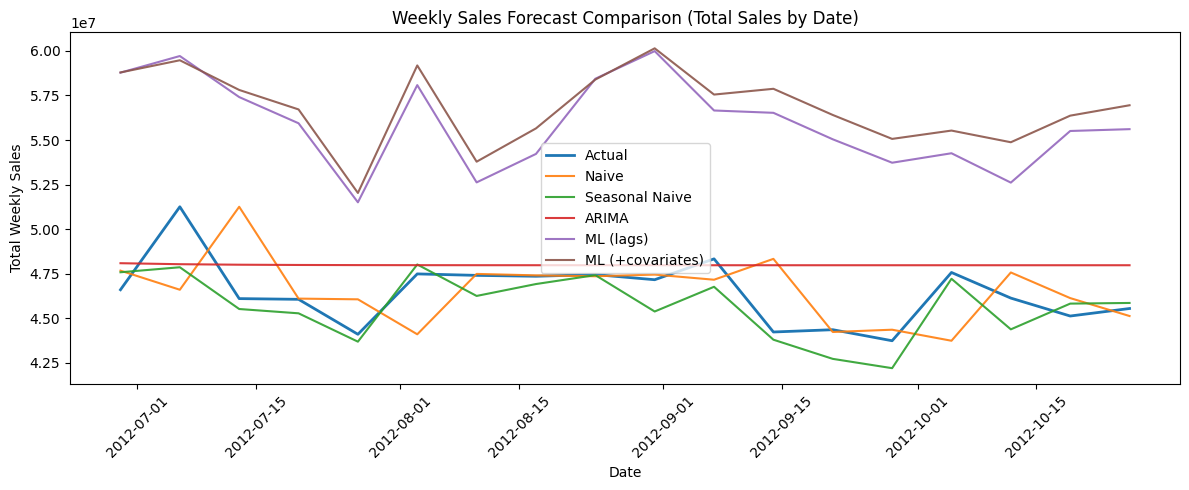

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

# If you already have statsmodels for ARIMA in your notebook:
from statsmodels.tsa.arima.model import ARIMA


# -------------------------------------------------------
# 1) BUILD A CLEAN DATE-LEVEL DATASET (one row per Date)
# -------------------------------------------------------
df = walmart_data.copy()
df["Date"] = pd.to_datetime(df["Date"])

# If you previously one-hot encoded Holiday_Flag, recover a single flag
if "Holiday_Flag" not in df.columns:
    hol_cols = [c for c in df.columns if c.startswith("Holiday_Flag_")]
    if hol_cols:
        # assumes columns like Holiday_Flag_0, Holiday_Flag_1
        df["Holiday_Flag"] = df[hol_cols].idxmax(axis=1).str.replace("Holiday_Flag_", "", regex=False).astype(int)
    else:
        df["Holiday_Flag"] = 0

# Aggregate to one row per Date
# Weekly_Sales: sum across stores
# Other covariates: mean across stores for that week (simple & common baseline)
df_total = (
    df.groupby("Date", as_index=False)
      .agg({
          "Weekly_Sales": "sum",
          "Holiday_Flag": "max",
          "Temperature": "mean",
          "Fuel_Price": "mean",
          "CPI": "mean",
          "Unemployment": "mean",
      })
      .sort_values("Date")
      .reset_index(drop=True)
)

# -------------------------------------------------------
# 2) FEATURE ENGINEERING: lags + rolling stats (date-level)
# -------------------------------------------------------
def make_total_ts_features(df_total, date_col="Date", target_col="Weekly_Sales"):
    d = df_total.copy()
    d[date_col] = pd.to_datetime(d[date_col])
    d = d.sort_values(date_col).reset_index(drop=True)

    # Calendar
    d["year"] = d[date_col].dt.year
    d["month"] = d[date_col].dt.month
    d["weekofyear"] = d[date_col].dt.isocalendar().week.astype(int)
    d["dayofweek"] = d[date_col].dt.dayofweek

    y = d[target_col]

    # Lags (weekly)
    for L in [1, 2, 3, 4, 8, 12, 26, 52]:
        d[f"lag_{L}"] = y.shift(L)

    # Rolling windows (shift first to avoid leakage)
    y_shift = y.shift(1)
    for w in [4, 8, 12, 26, 52]:
        d[f"roll_mean_{w}"] = y_shift.rolling(w).mean()
        d[f"roll_std_{w}"] = y_shift.rolling(w).std()

    return d

df_feat = make_total_ts_features(df_total)

# Choose feature sets
feature_cols_lags = [
    "year","month","weekofyear","dayofweek",
    *[c for c in df_feat.columns if c.startswith("lag_")],
    *[c for c in df_feat.columns if c.startswith("roll_")]
]

feature_cols_cov = feature_cols_lags + ["Holiday_Flag","Temperature","Fuel_Price","CPI","Unemployment"]

# Drop rows where lag/rolling features are not available
df_model = df_feat.dropna(subset=feature_cols_cov + ["Weekly_Sales"]).copy()
df_model = df_model.sort_values("Date").reset_index(drop=True)


# -------------------------------------------------------
# 3) CHRONOLOGICAL TRAIN/TEST SPLIT (80/20 by Date order)
# -------------------------------------------------------
cut_idx = int(len(df_model) * 0.8)

df_train = df_model.iloc[:cut_idx].copy()
df_test  = df_model.iloc[cut_idx:].copy()

y_train = df_train["Weekly_Sales"].copy()
y_test  = df_test["Weekly_Sales"].copy()

print("Train rows:", len(df_train), "| Test rows:", len(df_test))
print("Train dates:", df_train["Date"].min(), "->", df_train["Date"].max())
print("Test  dates:", df_test["Date"].min(), "->", df_test["Date"].max())


# -------------------------------------------------------
# 4) BASELINES: Naive + Seasonal Naive (date-level, aligned)
# -------------------------------------------------------
# Naive = last observed value from previous week
pred_naive = y_test.shift(1)

# Seasonal naive = value from 52 weeks ago
SEASON_LEN = 52
pred_seasonal_naive = df_model["Weekly_Sales"].shift(SEASON_LEN).iloc[cut_idx:].reset_index(drop=True)
pred_seasonal_naive.index = y_test.index  # align index to y_test


# -------------------------------------------------------
# 5) ARIMA (basic, but consistent)
# -------------------------------------------------------
# Keep it simple: (1,1,1) as a baseline; you can tune later
arima_model = ARIMA(y_train, order=(1, 1, 1)).fit()
pred_arima = pd.Series(arima_model.forecast(steps=len(y_test)), index=y_test.index, name="ARIMA")


# -------------------------------------------------------
# 6) ML MODEL: HistGradientBoosting (works without xgboost install)
#    - lags-only
#    - lags + covariates
# -------------------------------------------------------
# Lags-only
Xtr_lags = df_train[feature_cols_lags]
Xte_lags = df_test[feature_cols_lags]

ml_lags = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=2000,
    random_state=123
)
ml_lags.fit(Xtr_lags, y_train)
pred_ml_lags = pd.Series(ml_lags.predict(Xte_lags), index=y_test.index, name="ML (lags)")

# Lags + covariates
Xtr_cov = df_train[feature_cols_cov]
Xte_cov = df_test[feature_cols_cov]

ml_cov = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=2000,
    random_state=123
)
ml_cov.fit(Xtr_cov, y_train)
pred_ml_cov = pd.Series(ml_cov.predict(Xte_cov), index=y_test.index, name="ML (+covariates)")


# -------------------------------------------------------
# 7) COMPARISON TABLE + PLOT
# -------------------------------------------------------
comparison = pd.DataFrame({
    "Date": df_test["Date"].values,
    "Actual": y_test.values,
    "Naive": pred_naive.values,
    "Seasonal Naive": pred_seasonal_naive.values,
    "ARIMA": pred_arima.values,
    "ML (lags)": pred_ml_lags.values,
    "ML (+covariates)": pred_ml_cov.values,
}).set_index("Date")

# Drop rows where naive shifted is NaN (first test row)
comparison_clean = comparison.dropna()

# Metrics
rows = []
for col in comparison_clean.columns:
    if col == "Actual":
        continue
    mse = mean_squared_error(comparison_clean["Actual"], comparison_clean[col])
    r2  = r2_score(comparison_clean["Actual"], comparison_clean[col])
    rows.append({"Model": col, "MSE": mse, "R2": r2})

metrics = pd.DataFrame(rows).sort_values("MSE")
print(metrics.to_string(index=False))

# Plot
plt.figure(figsize=(12, 5))
plt.plot(comparison_clean.index, comparison_clean["Actual"], label="Actual", linewidth=2)

for col in comparison_clean.columns:
    if col == "Actual":
        continue
    plt.plot(comparison_clean.index, comparison_clean[col], label=col, alpha=0.9)

plt.title("Weekly Sales Forecast Comparison (Total Sales by Date)")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
